In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/used_car_price_dataset_extended.csv')

In [3]:
# ============= 1. Первичный анализ =============
print("1. Размер данных:", df.shape)
print("\n2. Типы данных:\n", df.dtypes)
print("\n3. Статистика числовых:\n", df.describe())
print("\n4. Уникальные значения категорий:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"  {col}: {df[col].nunique()} уникальных")

1. Размер данных: (10000, 12)

2. Типы данных:
 make_year               int64
mileage_kmpl          float64
engine_cc               int64
fuel_type                 str
owner_count             int64
price_usd             float64
brand                     str
transmission              str
color                     str
service_history           str
accidents_reported      int64
insurance_valid           str
dtype: object

3. Статистика числовых:
           make_year  mileage_kmpl     engine_cc   owner_count     price_usd  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean    2009.206900     17.960753   2287.130000      3.003500   7179.754532   
std        8.373858      5.025486   1291.276927      1.418904   2795.270940   
min     1995.000000      5.000000    800.000000      1.000000   1000.000000   
25%     2002.000000     14.540000   1200.000000      2.000000   5176.547500   
50%     2009.000000     17.970000   1800.000000      3.000000   6961.260000   

/var/folders/rp/rf6sk05976z3r0sdk1_hd45w0000gn/T/ipykernel_16975/805604966.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


In [4]:
# ============= 2. Анализ пропусков =============
print("\n5. Пропуски:")
print(df.isnull().sum())

# Особое внимание на service_history
print("\n6. service_history:")
print(df['service_history'].value_counts())
# Заполняем 'None.  -> 'Unknown'
df['service_history'] = df['service_history'].fillna('Unknown')



5. Пропуски:
make_year                0
mileage_kmpl             0
engine_cc                0
fuel_type                0
owner_count              0
price_usd                0
brand                    0
transmission             0
color                    0
service_history       2038
accidents_reported       0
insurance_valid          0
dtype: int64

6. service_history:
service_history
Full       4987
Partial    2975
Name: count, dtype: int64


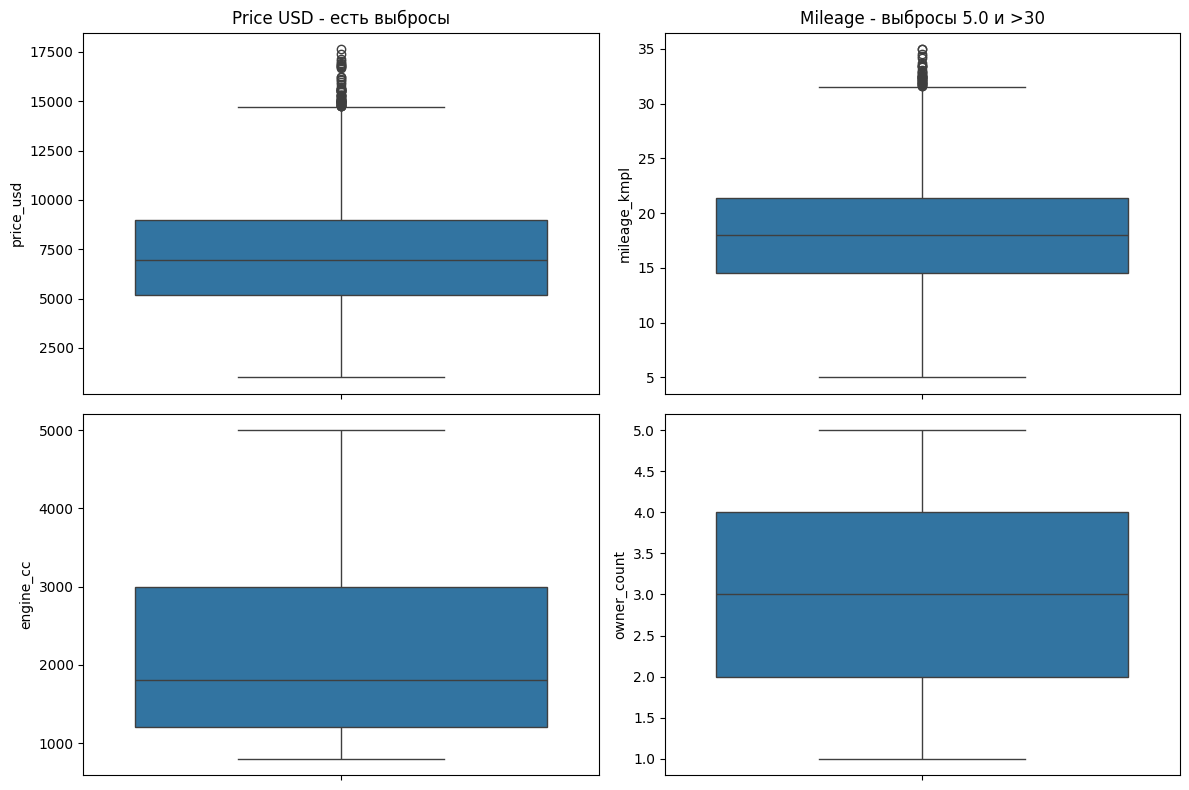

Осталось строк: 9947
Строк с mileage_kmpl == 5.0: 0


In [5]:
# ============= 3. Анализ выбросов =============
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.boxplot(data=df, y='price_usd', ax=axes[0,0])
axes[0,0].set_title('Price USD - есть выбросы')

sns.boxplot(data=df, y='mileage_kmpl', ax=axes[0,1])
axes[0,1].set_title('Mileage - выбросы 5.0 и >30')

sns.boxplot(data=df, y='engine_cc', ax=axes[1,0])
sns.boxplot(data=df, y='owner_count', ax=axes[1,1])
plt.tight_layout()
# plt.savefig('../reports/boxplots.png')  # ← ЗАКОММЕНТИРОВАТЬ
plt.show()
## Проверьте машины с расходом 5.0 км/л
#df[df['mileage_kmpl'] == 5.0][['brand', 'make_year', 'engine_cc', 'fuel_type', 'price_usd']]

df = df[df['mileage_kmpl'] != 5.0]

 # Проверьте машины с расходом 5.0 км/л
df[df['mileage_kmpl'] == 5.0][['brand', 'make_year', 'engine_cc', 'fuel_type', 'price_usd']]   

# После удаления
print(f"Осталось строк: {len(df)}")
print(f"Строк с mileage_kmpl == 5.0: {len(df[df['mileage_kmpl'] == 5.0])}")

In [7]:
# ============= 4. Feature Engineering =============
# Создаем возраст авто (предполагаем текущий год 2026)
df['car_age'] = 2026 - df['make_year']
print("\n7. Car age statistics:")
print(df['car_age'].describe())

# Можно удалить make_year, если используем car_age
df = df.drop('make_year', axis=1)


7. Car age statistics:
count    9947.000000
mean       16.793103
std         8.368584
min         3.000000
25%        10.000000
50%        17.000000
75%        24.000000
max        31.000000
Name: car_age, dtype: float64


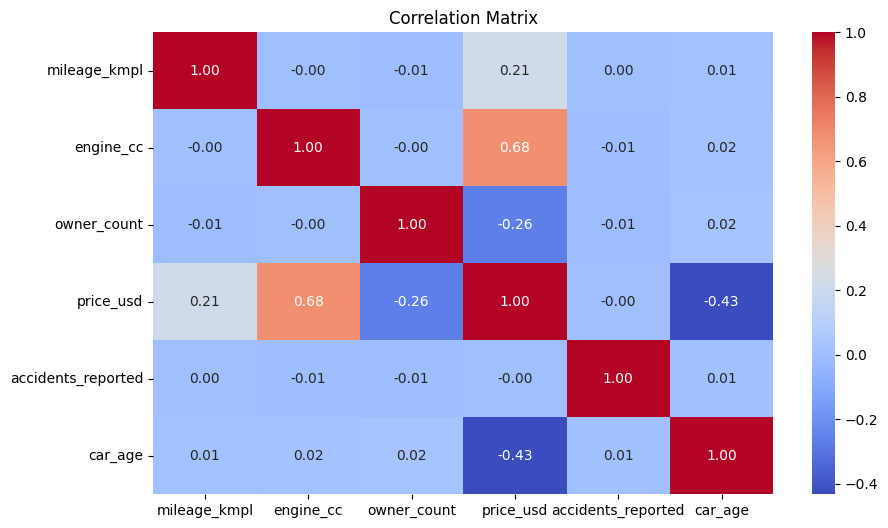

In [8]:
# ============= 5. Анализ корреляций =============
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

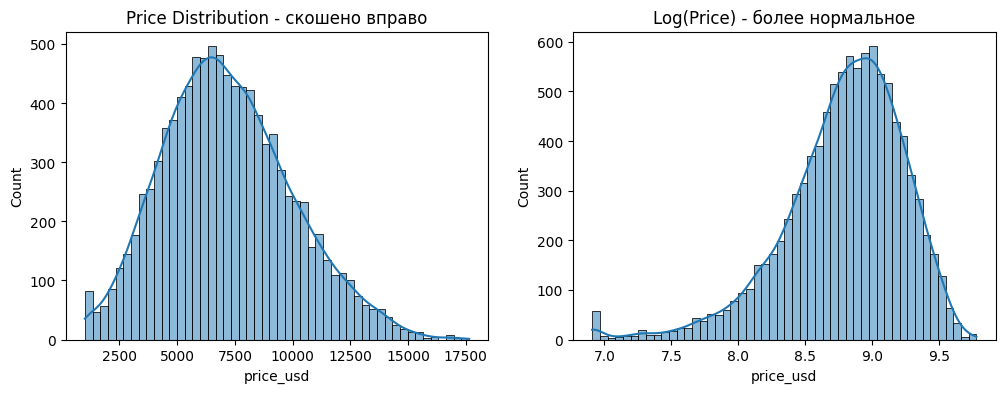

In [ ]:
# Вывод: price_usd сильно коррелирует с make_year/car_age и engine_cc

# ============= 6. Распределение целевой переменной =============
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['price_usd'], bins=50, kde=True)
plt.title('Price Distribution - скошено вправо')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price_usd']), bins=50, kde=True)
plt.title('Log(Price) - более нормальное')
plt.show()

#Для улучшения качества модели рекомендуется использовать log(price_usd) как целевую переменную.

In [14]:
# ============= 7. Сохраняем обработанные данные =============
df.to_csv('../data/processed/used_car_processed.csv', index=False)
print("\n8. Данные сохранены в data/processed/")


8. Данные сохранены в data/processed/
